<a href="https://colab.research.google.com/github/Pradeepa-murugesan/AI-Powered-Retail-Insights-and-Query-System/blob/main/ImageColorizerColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **<font color='blue'> Artistic Colorizer </font>**

#◢ DeOldify - Colorize your own photos!

####**Credits:**

Special thanks to:

Matt Robinson and María Benavente for pioneering the DeOldify image colab notebook.  

Dana Kelley for doing things, breaking stuff & having an opinion on everything.



---


#◢ Verify Correct Runtime Settings

**<font color='#FF000'> IMPORTANT </font>**

In the "Runtime" menu for the notebook window, select "Change runtime type." Ensure that the following are selected:
* Runtime Type = Python 3
* Hardware Accelerator = GPU


#◢ Git clone and install DeOldify

In [2]:
!git clone https://github.com/jantic/DeOldify.git DeOldify

fatal: destination path 'DeOldify' already exists and is not an empty directory.


In [3]:
cd DeOldify

/content/DeOldify


#◢ Setup

In [4]:
#NOTE:  This must be the first call in order to work properly!
from deoldify import device
from deoldify.device_id import DeviceId
#choices:  CPU, GPU0...GPU7
device.set(device=DeviceId.GPU0)

import torch

if not torch.cuda.is_available():
    print('GPU not available.')

In [5]:
!pip install -r requirements-colab.txt

In [6]:
import fastai
from deoldify.visualize import *
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*?Your .*? set is empty.*?")

INFO:numexpr.utils:NumExpr defaulting to 2 threads.


NumExpr defaulting to 2 threads.


In [7]:
!mkdir 'models'
!wget https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth -O ./models/ColorizeArtistic_gen.pth

mkdir: cannot create directory ‘models’: File exists
--2025-04-11 12:26:04--  https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth
Resolving data.deepai.org (data.deepai.org)... 143.244.50.91, 2400:52e0:1a01::954:1
Connecting to data.deepai.org (data.deepai.org)|143.244.50.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 255144681 (243M) [application/octet-stream]
Saving to: ‘./models/ColorizeArtistic_gen.pth’

./models/ColorizeAr 100%[===================>] 243.32M  4.88MB/s    in 50s     

2025-04-11 12:26:54 (4.89 MB/s) - ‘./models/ColorizeArtistic_gen.pth’ saved [255144681/255144681]



In [9]:
import collections.abc

# Monkey-patch collections with collections.abc to fix the Sized attribute
collections.Sized = collections.abc.Sized

colorizer = get_image_colorizer(artistic=True)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You 

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL builtins.slice was not an allowed global by default. Please use `torch.serialization.add_safe_globals([slice])` or the `torch.serialization.safe_globals([slice])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://

In [11]:
import collections.abc
import torch

# Monkey-patch collections with collections.abc to fix the Sized attribute
collections.Sized = collections.abc.Sized

# Load the colorizer with 'weights_only=False' to load the full state dictionary, and add safe globals
with torch.serialization.safe_globals([slice]):
    colorizer = get_image_colorizer(artistic=True)

# Alternatively, you can add safe globals permanently:
# torch.serialization.add_safe_globals([slice])

# The rest of the code remains the same...

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You 

#◢ Instructions

### source_url
Type in a url to a direct link of an image.  Usually that means they'll end in .png, .jpg, etc. NOTE: If you want to use your own image, upload it first to a site like Imgur.

### render_factor
The default value of 35 has been carefully chosen and should work -ok- for most scenarios (but probably won't be the -best-). This determines resolution at which the color portion of the image is rendered. Lower resolution will render faster, and colors also tend to look more vibrant. Older and lower quality images in particular will generally benefit by lowering the render factor. Higher render factors are often better for higher quality images, but the colors may get slightly washed out.

### watermarked
Selected by default, this places a watermark icon of a palette at the bottom left corner of the image.  This is intended to be a standard way to convey to others viewing the image that it is colorized by AI. We want to help promote this as a standard, especially as the technology continues to improve and the distinction between real and fake becomes harder to discern. This palette watermark practice was initiated and lead by the company MyHeritage in the MyHeritage In Color feature (which uses a newer version of DeOldify than what you're using here).

#### How to Download a Copy
Simply right click on the displayed image and click "Save image as..."!

## Pro Tips

You can evaluate how well the image is rendered at each render_factor by using the code at the bottom (that cell under "See how well render_factor values perform on a frame here").

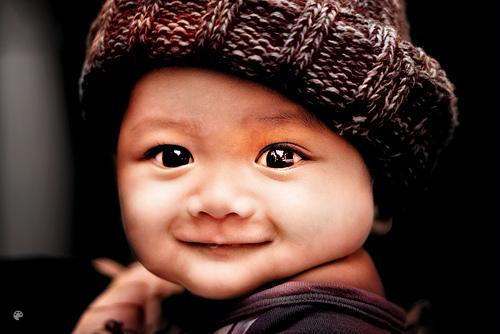

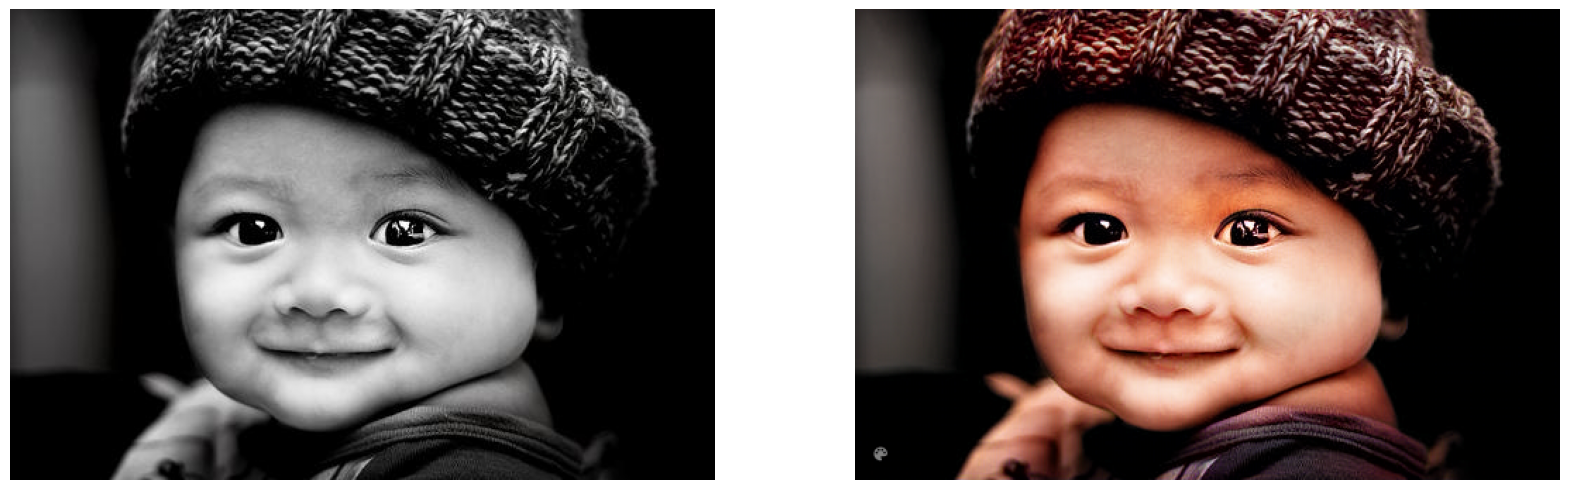

In [25]:
import requests
from io import BytesIO
from PIL import Image
import collections.abc
import torch

# Monkey-patch collections with collections.abc to fix the Sized attribute
collections.Sized = collections.abc.Sized

# Load the DeOldify colorizer
with torch.serialization.safe_globals([slice]):
    colorizer = get_image_colorizer(artistic=True)

# ✅ Direct image URL (NOT the webpage)
source_url = 'https://clipart-library.com/images/8TAbMpgzc.jpg'

render_factor = 35
watermarked = True

if source_url:
    try:
        response = requests.get(source_url, stream=True, headers={'User-Agent': 'Mozilla/5.0'})
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert('RGB')
        image.save('temp_image.jpg')
        image_path = colorizer.plot_transformed_image(path='temp_image.jpg', render_factor=render_factor, compare=True, watermarked=watermarked)
        show_image_in_notebook(image_path)
    except requests.exceptions.RequestException as e:
        print(f"Error downloading image from URL: {e}")
    except (Image.UnidentifiedImageError, OSError) as e:
        print(f"Error opening or processing image: {e}")
else:
    print('Provide an image url and try again.')


#◢ Colorize!!

## See how well render_factor values perform on the image here

In [27]:
for i in range(10,40,2):
    colorizer.plot_transformed_image('', render_factor=i, display_render_factor=True, figsize=(8,8))

FileNotFoundError: [Errno 2] No such file or directory: 'https:/clipart-library.com/images/8TAbMpgzc.jpg'

---
#⚙ Recommended image sources
* [/r/TheWayWeWere](https://www.reddit.com/r/TheWayWeWere/)